# CBIS-DDSM EDA

## Imports

In [9]:
!pip install Pillow

    PyYAML (>=5.1.*)
            ~~~~~~^


In [10]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## Metadata File Review

There is 2 files provided for each split:

### Train

- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv`
- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv`

### Test

- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_test_set.csv`
- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_test_set.csv`


And 2 meta files:

- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv`
- `datasets/cbis-ddsm-breast-cancer-image-dataset/csv/meta.csv`

In [18]:
train_set_mass_df = pd.read_csv("datasets/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv")
train_set_mass_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [26]:
test_set_mass_df = pd.read_csv("datasets/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_test_set.csv")

In [19]:
train_set_calc_df = pd.read_csv("datasets/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv")
train_set_calc_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [35]:
test_set_calc_df = pd.read_csv("datasets/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_test_set.csv")

In [20]:
dicom_info_df = pd.read_csv("datasets/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv")
dicom_info_df.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [21]:
meta_df = pd.read_csv("datasets/cbis-ddsm-breast-cancer-image-dataset/csv/meta.csv")
meta_df.head()

,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


The paper claims that there's 891 mass cases, for some reason we appear to have 892 in the dataset.

In [34]:
len(set(train_set_mass_df.patient_id.unique()) | set(test_set_mass_df.patient_id.unique()))

892

However, we have the correct number of calcification cases.

In [38]:
test_set_calc_df.patient_id.nunique() + train_set_calc_df.patient_id.nunique()

753

Let's have a closer look at one patient id to start with. Later we'll try to understand stastics for all patient ids.

In [45]:
patient_5 = train_set_calc_df[train_set_calc_df.patient_id == "P_00005"]

In [49]:
patient_5.iloc[0]

patient_id                                                           P_00005
breast density                                                             3
left or right breast                                                   RIGHT
image view                                                                CC
abnormality id                                                             1
abnormality type                                               calcification
calc type                                                          AMORPHOUS
calc distribution                                                  CLUSTERED
assessment                                                                 3
pathology                                                          MALIGNANT
subtlety                                                                   3
image file path            Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...
cropped image file path    Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...

In [61]:
patient_5_img_file = patient_5.iloc[0]["image file path"]
patient_5_img_file

'Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.9590.100.1.2.408909860712120272633130274602115723157/1.3.6.1.4.1.9590.100.1.2.47414316010368386519740343172775938548/000000.dcm'

In [51]:
patient_5.iloc[0]["ROI mask file path"]

'Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081/1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682/000000.dcm'

In [59]:
dict(patient_5.iloc[0])

{'patient_id': 'P_00005',
 'breast density': np.int64(3),
 'left or right breast': 'RIGHT',
 'image view': 'CC',
 'abnormality id': np.int64(1),
 'abnormality type': 'calcification',
 'calc type': 'AMORPHOUS',
 'calc distribution': 'CLUSTERED',
 'assessment': np.int64(3),
 'pathology': 'MALIGNANT',
 'subtlety': np.int64(3),
 'image file path': 'Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.9590.100.1.2.408909860712120272633130274602115723157/1.3.6.1.4.1.9590.100.1.2.47414316010368386519740343172775938548/000000.dcm',
 'cropped image file path': 'Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081/1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682/000001.dcm\n',
 'ROI mask file path': 'Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.328778919012412769218080124214088709081/1.3.6.1.4.1.9590.100.1.2.393344010211719049419601138200355094682/000000.dcm'}

In [64]:
patient_5_id = patient_5_img_file.split("/")[1]
patient_5_id

'1.3.6.1.4.1.9590.100.1.2.408909860712120272633130274602115723157'

In [72]:
dicom_5_row = dicom_info_df[dicom_info_df.StudyInstanceUID == patient_5_id]
dicom_5_row

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
2360,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.47414...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.474143...,NaN,16,16,BREAST,2761,20160503,105435.478,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.474143160103683865197...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.408909860712120272633...,161037.0


In [74]:
dict(dicom_5_row.iloc[0])

{'file_path': 'CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.47414316010368386519740343172775938548/1-188.dcm',
 'image_path': 'CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.47414316010368386519740343172775938548/1-188.jpg',
 'AccessionNumber': np.float64(nan),
 'BitsAllocated': np.int64(16),
 'BitsStored': np.int64(16),
 'BodyPartExamined': 'BREAST',
 'Columns': np.int64(2761),
 'ContentDate': np.int64(20160503),
 'ContentTime': np.float64(105435.478),
 'ConversionType': 'WSD',
 'HighBit': np.int64(15),
 'InstanceNumber': np.int64(1),
 'LargestImagePixelValue': np.int64(65535),
 'Laterality': 'R',
 'Modality': 'MG',
 'PatientBirthDate': np.float64(nan),
 'PatientID': 'Calc-Training_P_00005_RIGHT_CC',
 'PatientName': 'Calc-Training_P_00005_RIGHT_CC',
 'PatientOrientation': 'CC',
 'PatientSex': np.float64(nan),
 'PhotometricInterpretation': 'MONOCHROME2',
 'PixelRepresentation': np.int64(0),
 'ReferringPhysicianName': np.float64(nan),
 'Rows': np.int64(5056),
 'SOPClassUID': '1.2.840.10008.5.1.4.1

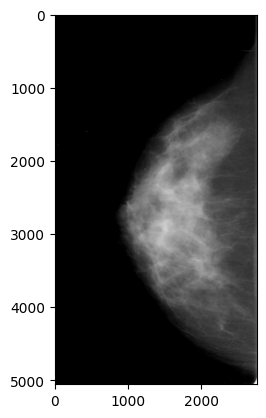

In [12]:
plt.imshow(
    Image.open(Path("datasets/cbis-ddsm-breast-cancer-image-dataset/") /
               "jpeg/1.3.6.1.4.1.9590.100.1.2.47414316010368386519740343172775938548/1-188.jpg"),
    cmap="gray"
)